# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from art.utils import load_mnist
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import VirtualAdversarialMethod

import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)
_ = torch.manual_seed(42)

# Load Data

In [3]:
(x_train, y_train), (x_test, y_test), min_pixel_value, max_pixel_value = load_mnist()

In [4]:
x_train = np.transpose(x_train, (0, 3, 1, 2)).astype(np.float32)
x_test = np.transpose(x_test, (0, 3, 1, 2)).astype(np.float32)

In [5]:
x_train.shape, x_test.shape, min_pixel_value, max_pixel_value

((60000, 1, 28, 28), (10000, 1, 28, 28), 0.0, 1.0)

# Model

In [6]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=1)

In [7]:
class ProbabilityCrossEntropyLoss(nn.NLLLoss):
    def forward(self, probabilities, target):
        return super().forward(torch.log(probabilities + 1e-12), target)

In [8]:
model = Net()

In [9]:
classifier = PyTorchClassifier(
    model=model,
    loss=ProbabilityCrossEntropyLoss(),
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3),
    input_shape=(1, 28, 28),
    nb_classes=10,
    clip_values=(min_pixel_value, max_pixel_value)
)

In [10]:
classifier.fit(x_train, y_train, batch_size=256, nb_epochs=5, verbose=False)

In [11]:
predictions = classifier.predict(x_test)
clean_accuracy = np.mean(np.argmax(predictions, axis=1) == np.argmax(y_test, axis=1))
print("Clean Test Accuracy:", clean_accuracy)

Clean Test Accuracy: 0.9865


# Attack

In [13]:
num_samples = 200
x_sample = x_test[:num_samples]
y_sample = y_test[:num_samples]

In [14]:
attack = VirtualAdversarialMethod(
    classifier=classifier,
    max_iter=5,
    finite_diff=1e-6,
    eps=5.0,
    batch_size=64,
)

In [15]:
x_test_adv = attack.generate(x=x_sample)

VAT:   0%|          | 0/4 [00:00<?, ?it/s]

# Results

In [16]:
clean_preds = classifier.predict(x_sample)
adv_preds = classifier.predict(x_test_adv)

In [17]:
y_true = np.argmax(y_sample, axis=1)
clean_labels = np.argmax(clean_preds, axis=1)
adv_labels = np.argmax(adv_preds, axis=1)

In [18]:
print("Accuracy on Clean Samples:", np.mean(clean_labels == y_true))
print("Accuracy on Adversarial Samples:", np.mean(adv_labels == y_true))
print("Changed Predictions:", np.sum(clean_labels != adv_labels), "/", num_samples)

Accuracy on Clean Samples: 0.995
Accuracy on Adversarial Samples: 0.93
Changed Predictions: 13 / 200


In [19]:
perturbation = x_test_adv - x_sample
print("L-inf Norm:", np.abs(perturbation).max())
print("Mean L2 Norm:", np.linalg.norm(perturbation.reshape(num_samples, -1), axis=1).mean())

L-inf Norm: 1.0
Mean L2 Norm: 3.334068


In [20]:
kl = np.sum(clean_preds * (np.log(clean_preds + 1e-12) - np.log(adv_preds + 1e-12)), axis=1)
print("Mean KL Divergence:", kl.mean())

Mean KL Divergence: 0.32342792


In [21]:
for eps in [0.5, 2.0, 5.0, 10.0]:
    sweep_attack = VirtualAdversarialMethod(classifier=classifier, max_iter=5, eps=eps, batch_size=64, verbose=False)
    x_sweep = sweep_attack.generate(x=x_sample)
    sweep_acc = np.mean(np.argmax(classifier.predict(x_sweep), axis=1) == y_true)
    l2 = np.linalg.norm((x_sweep - x_sample).reshape(num_samples, -1), axis=1).mean()
    print(f"eps={eps:5.1f}  accuracy={sweep_acc:.3f}  mean L2={l2:.3f}")

eps=  0.5  accuracy=1.000  mean L2=0.354
eps=  2.0  accuracy=0.965  mean L2=1.419
eps=  5.0  accuracy=0.930  mean L2=3.476
eps= 10.0  accuracy=0.875  mean L2=6.385


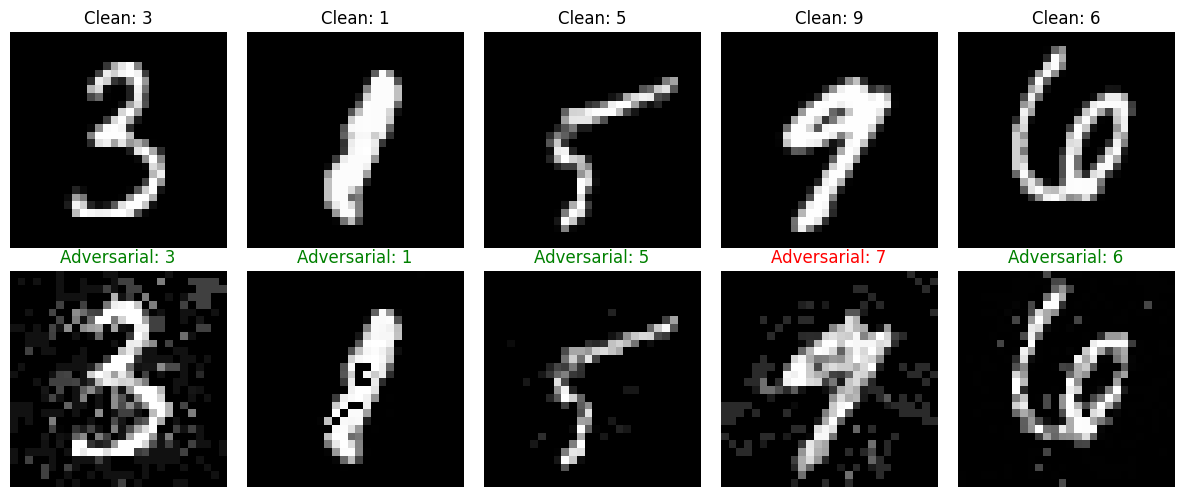

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 5))
random_index = np.random.randint(0, num_samples, 5)

for i, idx in enumerate(random_index):
    axes[0, i].imshow(x_sample[idx][0], cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Clean: {clean_labels[idx]}')

    color = 'green' if adv_labels[idx] == y_true[idx] else 'red'
    axes[1, i].imshow(x_test_adv[idx][0], cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Adversarial: {adv_labels[idx]}', color=color)

plt.tight_layout()
plt.show()